<a href="https://colab.research.google.com/github/ShivaniMareddy/Transformer/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruvildave/en-fr-translation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'en-fr-translation-dataset' dataset.
Path to dataset files: /kaggle/input/en-fr-translation-dataset


In [ ]:
import pandas as pd
import os

print(os.listdir(path))

['en-fr.csv']


In [ ]:
df = pd.read_csv(
    "/kaggle/input/en-fr-translation-dataset/en-fr.csv",
    nrows=100000
)

# Task 1: Data Preparation

In [ ]:
import pandas as pd
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
print(df.head())
print(df.shape)

                                                  en  \
0  Changing Lives | Changing Society | How It Wor...   
1                                           Site map   
2                                           Feedback   
3                                            Credits   
4                                           Français   

                                                  fr  
0  Il a transformé notre vie | Il a transformé la...  
1                                       Plan du site  
2                                        Rétroaction  
3                                            Crédits  
4                                            English  
(100000, 2)


In [ ]:
def clean_text(text):
    text = str(text).lower()

    # Keep alphabets, accents, spaces and punctuation
    text = re.sub(r"[^a-zA-ZÀ-ÿ?.!, ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df['en'] = df['en'].apply(clean_text)
df['fr'] = df['fr'].apply(clean_text)

In [ ]:
df['fr'] = df['fr'].apply(
    lambda x: "<start> " + x + " <end>"
)

In [ ]:
print(df['en'].iloc[0])
print(df['fr'].iloc[0])

changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page
<start> il a transformé notre vie il a transformé la société son fonctionnement la technologie, moteur du changement accueil concepts enseignants recherche aperçu collaborateurs web hhcc ressources commentaires musée virtuel du canada <end>


In [ ]:
MAX_LEN = 50

df = df[
    (df['en'].str.split().str.len() <= MAX_LEN) &
    (df['fr'].str.split().str.len() <= MAX_LEN)
]

In [ ]:
english_sentences = df['en'].tolist()
french_sentences = df['fr'].tolist()

In [ ]:
eng_tokenizer = Tokenizer(
    num_words=15000,
    filters='',
    oov_token='<unk>'
)

fr_tokenizer = Tokenizer(
    num_words=15000,
    filters='',
    oov_token='<unk>'
)

eng_tokenizer.fit_on_texts(english_sentences)
fr_tokenizer.fit_on_texts(french_sentences)

In [ ]:
encoder_sequences = eng_tokenizer.texts_to_sequences(english_sentences)
decoder_sequences = fr_tokenizer.texts_to_sequences(french_sentences)

In [ ]:
eng_vocab_size = min(
    len(eng_tokenizer.word_index) + 1,
    15000
)

fr_vocab_size = min(
    len(fr_tokenizer.word_index) + 1,
    15000
)

print("English Vocabulary:", eng_vocab_size)
print("French Vocabulary:", fr_vocab_size)

English Vocabulary: 15000
French Vocabulary: 15000


In [ ]:
max_eng_len = max(len(seq) for seq in encoder_sequences)
max_fr_len = max(len(seq) for seq in decoder_sequences)

print(max_eng_len)
print(max_fr_len)

50
50


In [ ]:
print(english_sentences[0])
print(encoder_sequences[0])

changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page
[1474, 3266, 1474, 1128, 317, 31, 891, 315, 8457, 548, 341, 3723, 5331, 830, 393, 5655, 1, 330, 1022, 3596, 2488, 1310, 3, 11, 341, 267]


In [ ]:
encoder_input = pad_sequences(
    encoder_sequences,
    maxlen=max_eng_len,
    padding='post'
)

decoder_input = pad_sequences(
    decoder_sequences,
    maxlen=max_fr_len,
    padding='post'
)

In [ ]:
print("Encoder Shape:", encoder_input.shape)
print("Decoder Shape:", decoder_input.shape)

Encoder Shape: (94823, 50)
Decoder Shape: (94823, 50)


In [ ]:
print(max_eng_len)
print(max_fr_len)

eng_lengths = [len(seq) for seq in encoder_sequences]
fr_lengths = [len(seq) for seq in decoder_sequences]

print("Average English Length:", np.mean(eng_lengths))
print("Average French Length:", np.mean(fr_lengths))

50
50
Average English Length: 16.352098119654514
Average French Length: 21.430844837223038


In [ ]:
longest_idx = np.argmax(eng_lengths)

print(df['en'].iloc[longest_idx][:1000])

shahid javadesarfaraz, ostadmotahari avenue , tehran, iran p.o. box tehran, iran telephone fax email terandfaitmaeci.gc.ca canadian trade commissioner service market information on iran httpwww.infoexport.gc.ca agrifood trade service at a glance fact sheet httpats.agr.castatsirane.htm presidency of the islamic republic of iran httpwww.president.ireng statistical centre of iran httpwww.sci.or.irindex.htm government trading corporation httpwww.gtcir.com


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding

In [ ]:
d_model = 128

embedding_layer = Embedding(
    input_dim=eng_vocab_size,
    output_dim=d_model
)

In [ ]:
encoder_embeddings = embedding_layer(
    encoder_input
)

In [ ]:
print(encoder_embeddings.shape)

(94823, 50, 128)


In [ ]:
print(encoder_embeddings[0][0])

tf.Tensor(
[-0.00076492  0.01490656 -0.02576642 -0.00824587  0.03308446  0.03683246
  0.01310125  0.03613787  0.03618446  0.01366263 -0.00605702  0.02059967
  0.03039524  0.0258528  -0.0305512  -0.02263643 -0.04728089 -0.01586728
  0.04163252  0.01326866 -0.01956059  0.03129948  0.00704806 -0.04642652
 -0.00519625  0.02367296  0.0252442  -0.00596988 -0.03624164 -0.02491577
  0.03900651  0.01375746  0.02010633  0.01474078 -0.03343699 -0.00026989
  0.00796627 -0.01852863  0.00172939  0.03100189 -0.02496554  0.0123313
  0.02352674 -0.00689328  0.0013593  -0.02150021  0.03076133  0.01725986
  0.00452349 -0.04725274 -0.00568253  0.0371904  -0.01809971 -0.00764644
  0.01875729  0.02703648  0.0163298   0.02647194  0.04685492 -0.01008268
 -0.03972233  0.00216772  0.01502125  0.04396443  0.01025531 -0.01341578
 -0.02338833  0.00537433 -0.0425519  -0.03336332  0.02954579 -0.04094826
  0.02335114  0.01009493 -0.00204407  0.00243567  0.03876552 -0.01663923
 -0.03808524  0.04505005 -0.04108367  0.0

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
def positional_encoding(position, d_model):

    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000,
        (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model)
    )

    pos_encoding = np.zeros((position, d_model))

    # Even indices → sin
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # Odd indices → cos
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pos_encoding = pos_encoding[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)

In [ ]:
d_model = 128

pos_encoding = positional_encoding(
    position=max_eng_len,
    d_model=d_model
)

print(pos_encoding.shape)

(1, 50, 128)


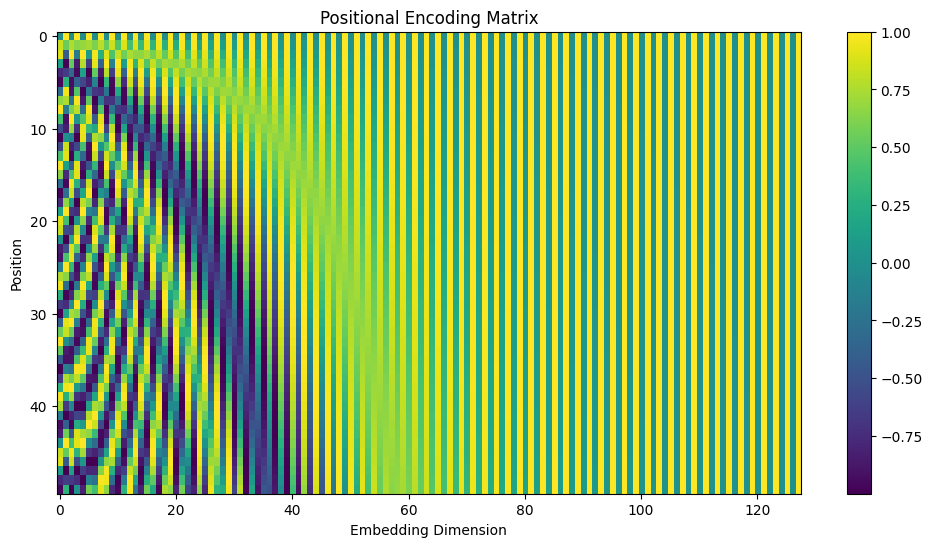

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.imshow(pos_encoding[0], aspect='auto')

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title("Positional Encoding Matrix")

plt.show()

In [ ]:
print(encoder_embeddings.shape)

(94823, 50, 128)


In [ ]:
transformer_input = (
    encoder_embeddings +
    pos_encoding[:, :max_eng_len, :]
)

In [ ]:
print(transformer_input.shape)

(94823, 50, 128)


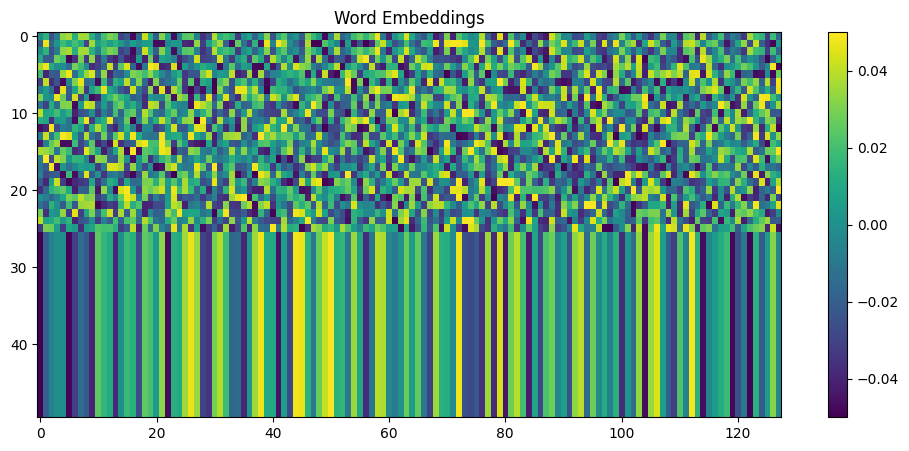

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    encoder_embeddings[0].numpy(),
    aspect='auto'
)

plt.colorbar()
plt.title("Word Embeddings")
plt.show()

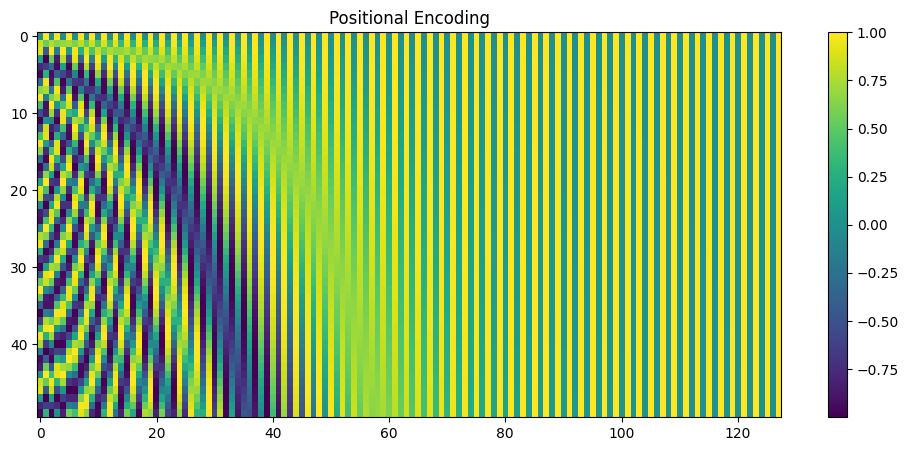

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    pos_encoding[0],
    aspect='auto'
)

plt.colorbar()
plt.title("Positional Encoding")
plt.show()

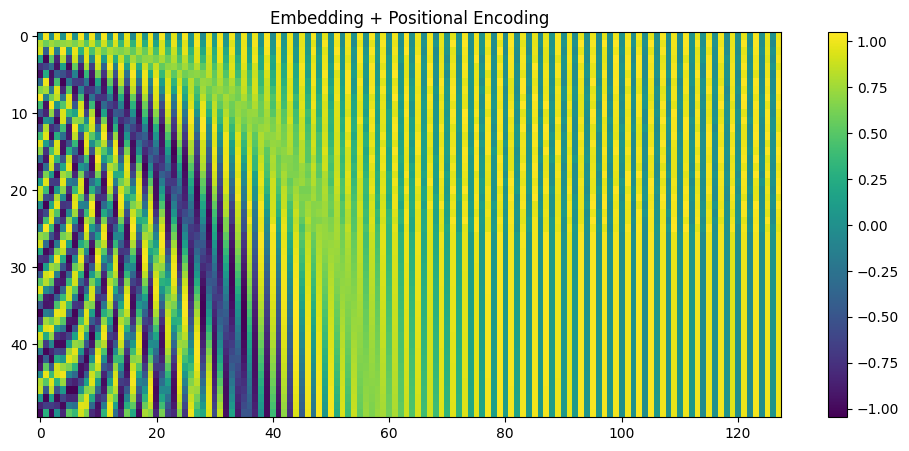

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    transformer_input[0].numpy(),
    aspect='auto'
)

plt.colorbar()
plt.title("Embedding + Positional Encoding")
plt.show()

In [ ]:
transformer_input = encoder_embeddings + pos_encoding[:, :max_eng_len, :]

In [ ]:
print("Embedding Shape:", encoder_embeddings.shape)
print("Positional Encoding Shape:", pos_encoding.shape)
print("Transformer Input Shape:", transformer_input.shape)

Embedding Shape: (94823, 50, 128)
Positional Encoding Shape: (1, 50, 128)
Transformer Input Shape: (94823, 50, 128)


In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
def scaled_dot_product_attention(Q, K, V):

    matmul_qk = tf.matmul(Q, K, transpose_b=True)

    dk = tf.cast(tf.shape(K)[-1], tf.float32)

    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    attention_weights = tf.nn.softmax(
        scaled_attention_logits,
        axis=-1
    )

    output = tf.matmul(
        attention_weights,
        V
    )

    return output, attention_weights, scaled_attention_logits

In [ ]:
words = ["The", "cat", "chased", "the", "mouse"]

seq_len = len(words)

d_model = 128

In [ ]:
sample_embeddings = tf.random.normal(
    (1, seq_len, d_model)
)

In [ ]:
Q = sample_embeddings
K = sample_embeddings
V = sample_embeddings

In [ ]:
context_vectors, attention_weights, attention_scores = (
    scaled_dot_product_attention(Q, K, V)
)

In [ ]:
print("Attention Scores Shape:")
print(attention_scores.shape)

print(attention_scores[0])

Attention Scores Shape:
(1, 5, 5)
tf.Tensor(
[[11.134642    0.4771003   0.25981066 -0.43979132 -1.6719297 ]
 [ 0.4771003  11.578671    0.08998293  0.30413345 -1.4496387 ]
 [ 0.25981066  0.08998293 10.0720005  -0.6408518   0.23170365]
 [-0.43979132  0.30413345 -0.6408518  12.006519   -1.1894753 ]
 [-1.6719297  -1.4496387   0.23170365 -1.1894753  12.659353  ]], shape=(5, 5), dtype=float32)


In [ ]:
print("Attention Weights")

print(attention_weights[0])

Attention Weights
tf.Tensor(
[[9.9994540e-01 2.3521494e-05 1.8927669e-05 9.4029429e-06 2.7425415e-06]
 [1.5087994e-05 9.9995983e-01 1.0244919e-05 1.2691498e-05 2.1971489e-06]
 [5.4770073e-05 4.6215559e-05 9.9982351e-01 2.2253105e-05 5.3252104e-05]
 [3.9321340e-06 8.2739116e-06 3.2159476e-06 9.9998271e-01 1.8579968e-06]
 [5.9703575e-07 7.4565861e-07 4.0062459e-06 9.6722499e-07 9.9999368e-01]], shape=(5, 5), dtype=float32)


In [ ]:
print("Context Vector Shape:")

print(context_vectors.shape)

Context Vector Shape:
(1, 5, 128)


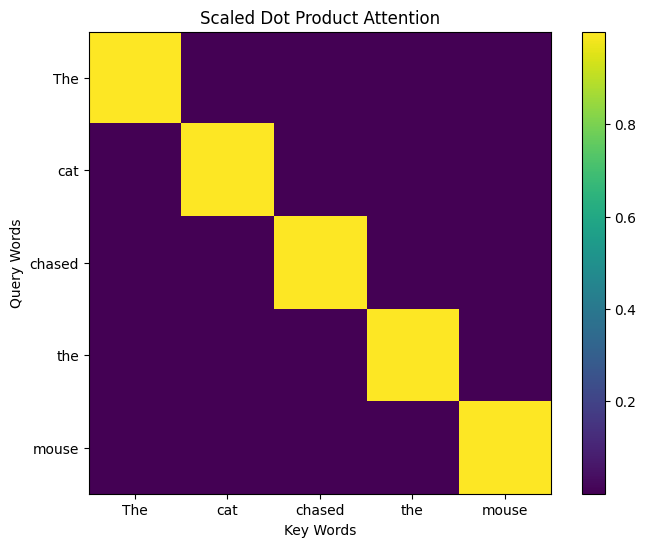

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    attention_weights[0],
    cmap='viridis'
)

plt.colorbar()

plt.xticks(
    range(len(words)),
    words
)

plt.yticks(
    range(len(words)),
    words
)

plt.xlabel("Key Words")
plt.ylabel("Query Words")

plt.title(
    "Scaled Dot Product Attention"
)

plt.show()

In [ ]:
import tensorflow as tf

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads):
        super().__init__()

        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        self.Wq = tf.keras.layers.Dense(d_model)
        self.Wk = tf.keras.layers.Dense(d_model)
        self.Wv = tf.keras.layers.Dense(d_model)

        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):

        x = tf.reshape(
            x,
            (batch_size, -1, self.num_heads, self.depth)
        )

        return tf.transpose(
            x,
            perm=[0,2,1,3]
        )

    def call(self, v, k, q):

        batch_size = tf.shape(q)[0]

        Q = self.Wq(q)
        K = self.Wk(k)
        V = self.Wv(v)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        attention_output, attention_weights, _ = (
            scaled_dot_product_attention(
                Q, K, V
            )
        )

        attention_output = tf.transpose(
            attention_output,
            perm=[0,2,1,3]
        )

        concat_attention = tf.reshape(
            attention_output,
            (batch_size, -1, self.d_model)
        )

        output = self.dense(
            concat_attention
        )

        return output, attention_weights

In [ ]:
d_model = 128
num_heads = 4

mha = MultiHeadAttention(
    d_model=d_model,
    num_heads=num_heads
)

In [ ]:
words = ["The", "cat", "chased", "the", "mouse"]

sample_embeddings = tf.random.normal(
    (1, 5, d_model)
)

In [ ]:
output, attention_weights = mha(
    sample_embeddings,
    sample_embeddings,
    sample_embeddings
)

In [ ]:
print("Output Shape:")
print(output.shape)

print("Attention Shape:")
print(attention_weights.shape)

Output Shape:
(1, 5, 128)
Attention Shape:
(1, 4, 5, 5)


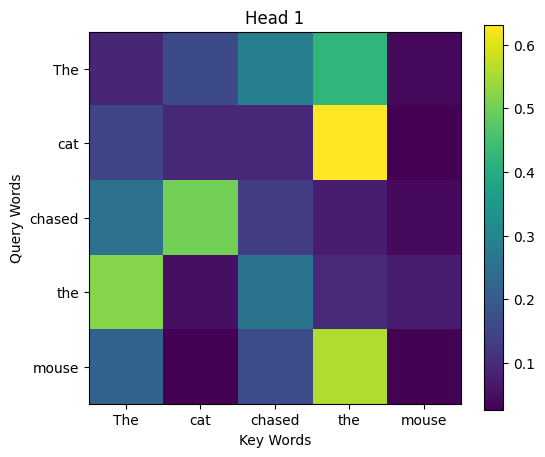

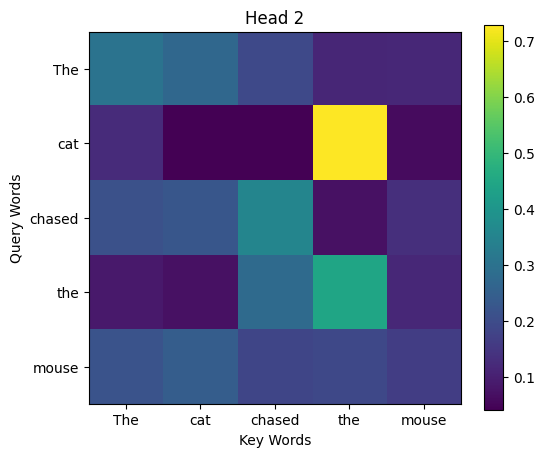

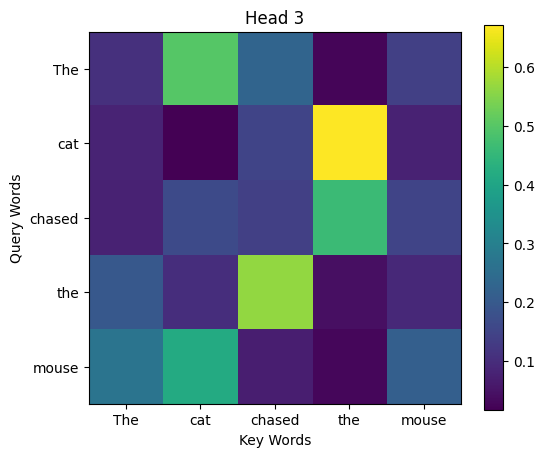

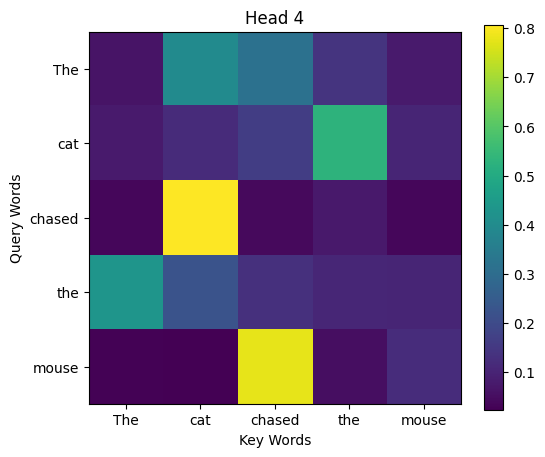

In [ ]:
import matplotlib.pyplot as plt

head_names = [
    "Head 1",
    "Head 2",
    "Head 3",
    "Head 4"
]

for head in range(4):

    plt.figure(figsize=(6,5))

    plt.imshow(
        attention_weights[0, head],
        cmap='viridis'
    )

    plt.colorbar()

    plt.xticks(
        range(len(words)),
        words
    )

    plt.yticks(
        range(len(words)),
        words
    )

    plt.title(head_names[head])

    plt.xlabel("Key Words")
    plt.ylabel("Query Words")

    plt.show()

In [ ]:
for head in range(4):
    print(f"\nHead {head+1}")
    print(
        attention_weights[0, head].numpy()
    )


Head 1
[[0.09131447 0.16101508 0.28526428 0.42447633 0.03792993]
 [0.15299141 0.09650379 0.09441637 0.6304085  0.02567995]
 [0.25033358 0.5022604  0.13469048 0.07126247 0.04145305]
 [0.5198988  0.05088335 0.25755212 0.09876853 0.07289717]
 [0.21513835 0.03027608 0.16716039 0.55797756 0.02944765]]

Head 2
[[0.30420858 0.2705701  0.19225197 0.11555956 0.11740983]
 [0.12695362 0.04141206 0.04315463 0.72807515 0.06040459]
 [0.21295945 0.22432081 0.35480028 0.07322305 0.13469633]
 [0.08800276 0.07140254 0.2782423  0.44429827 0.11805414]
 [0.2164144  0.24439016 0.18440115 0.18943495 0.16535935]]

Head 3
[[0.10620479 0.4995395  0.22832805 0.0243771  0.14155059]
 [0.0829139  0.01654896 0.15171997 0.6708193  0.07799787]
 [0.07930364 0.16395463 0.14178006 0.463117   0.15184467]
 [0.19784431 0.10343778 0.56400687 0.04342189 0.09128921]
 [0.26895452 0.41555223 0.07159606 0.02804541 0.2158518 ]]

Head 4
[[0.06580371 0.39842975 0.31420708 0.1405156  0.08104383]
 [0.08005875 0.11964823 0.16653189 0.

In [ ]:
def point_wise_feed_forward_network(
    d_model,
    dff
):

    return tf.keras.Sequential([
        tf.keras.layers.Dense(
            dff,
            activation='relu'
        ),

        tf.keras.layers.Dense(
            d_model
        )
    ])

In [ ]:
class EncoderLayer(tf.keras.layers.Layer):

    def __init__(
        self,
        d_model,
        num_heads,
        dff,
        rate=0.1
    ):

        super().__init__()

        self.mha = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = point_wise_feed_forward_network(
            d_model,
            dff
        )

        self.layernorm1 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.layernorm2 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.dropout1 = tf.keras.layers.Dropout(rate)

        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(
        self,
        x,
        training=False
    ):

        attn_output, attn_weights = self.mha(
            x,
            x,
            x
        )

        attn_output = self.dropout1(
            attn_output,
            training=training
        )

        out1 = self.layernorm1(
            x + attn_output
        )

        ffn_output = self.ffn(
            out1
        )

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        out2 = self.layernorm2(
            out1 + ffn_output
        )

        return out2, attn_weights

In [ ]:
class Encoder(tf.keras.layers.Layer):

    def __init__(
        self,
        num_layers,
        d_model,
        num_heads,
        dff,
        input_vocab_size,
        maximum_position_encoding,
        rate=0.1
    ):

        super().__init__()

        self.d_model = d_model

        self.num_layers = num_layers

        self.embedding = (
            tf.keras.layers.Embedding(
                input_vocab_size,
                d_model
            )
        )

        self.pos_encoding = positional_encoding(
            maximum_position_encoding,
            d_model
        )

        self.enc_layers = [

            EncoderLayer(
                d_model,
                num_heads,
                dff,
                rate
            )

            for _ in range(num_layers)
        ]

        self.dropout = (
            tf.keras.layers.Dropout(rate)
        )

    def call(
        self,
        x,
        training=False
    ):

        seq_len = tf.shape(x)[1]

        x = self.embedding(x)

        x *= tf.math.sqrt(
            tf.cast(
                self.d_model,
                tf.float32
            )
        )

        x += self.pos_encoding[
            :,
            :seq_len,
            :
        ]

        x = self.dropout(
            x,
            training=training
        )

        attention_maps = []

        for i in range(
            self.num_layers
        ):

            x, attn = self.enc_layers[i](
                x,
                training=training
            )

            attention_maps.append(attn)

        return x, attention_maps

In [ ]:
num_layers = 2

d_model = 128

num_heads = 4

dff = 512

input_vocab_size = eng_vocab_size

max_position = 50

In [ ]:
encoder = Encoder(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    max_position
)

In [ ]:
sample_input = encoder_input[:32]

In [ ]:
encoder_output, attention_maps = encoder(
    sample_input,
    training=False
)

In [ ]:
print(
    "Encoder Output Shape:"
)

print(
    encoder_output.shape
)

Encoder Output Shape:
(32, 50, 128)


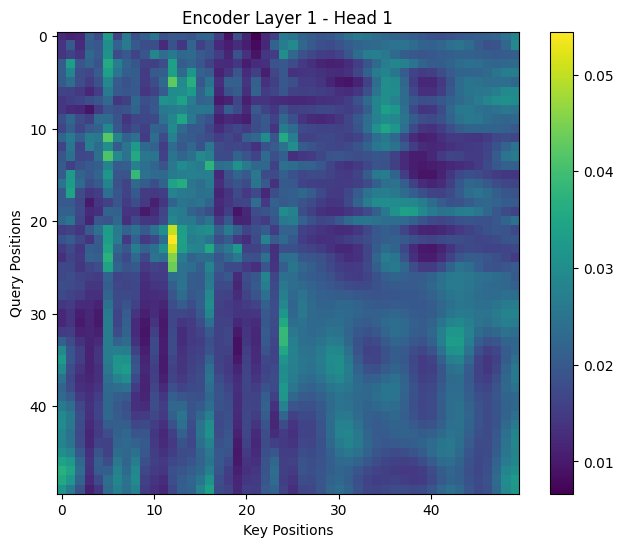

In [ ]:
import matplotlib.pyplot as plt

attention = attention_maps[0][0,0]

plt.figure(figsize=(8,6))

plt.imshow(
    attention,
    cmap='viridis'
)

plt.colorbar()

plt.title(
    "Encoder Layer 1 - Head 1"
)

plt.xlabel("Key Positions")
plt.ylabel("Query Positions")

plt.show()

In [ ]:
import tensorflow as tf

def create_look_ahead_mask(size):

    mask = 1 - tf.linalg.band_part(
        tf.ones((size, size)),
        -1,
        0
    )

    return mask

In [ ]:
mask = create_look_ahead_mask(5)

print(mask)

tf.Tensor(
[[0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]], shape=(5, 5), dtype=float32)


In [ ]:
class DecoderLayer(tf.keras.layers.Layer):

    def __init__(self,
                 d_model,
                 num_heads,
                 dff,
                 rate=0.1):

        super().__init__()

        self.mha1 = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.mha2 = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = point_wise_feed_forward_network(
            d_model,
            dff
        )

        self.layernorm1 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6
        )

        self.layernorm2 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6
        )

        self.layernorm3 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6
        )

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.dropout3 = tf.keras.layers.Dropout(rate)

    def call(self,
             x,
             enc_output,
             training=False):

        # Block 1
        attn1, attn_weights1 = self.mha1(
            x,
            x,
            x
        )

        attn1 = self.dropout1(
            attn1,
            training=training
        )

        out1 = self.layernorm1(
            x + attn1
        )

        # Block 2 (Cross Attention)

        attn2, attn_weights2 = self.mha2(
            enc_output,
            enc_output,
            out1
        )

        attn2 = self.dropout2(
            attn2,
            training=training
        )

        out2 = self.layernorm2(
            out1 + attn2
        )

        # Feed Forward

        ffn_output = self.ffn(
            out2
        )

        ffn_output = self.dropout3(
            ffn_output,
            training=training
        )

        out3 = self.layernorm3(
            out2 + ffn_output
        )

        return (
            out3,
            attn_weights1,
            attn_weights2
        )

In [ ]:
print(DecoderLayer.call)

<function DecoderLayer.call at 0x7f4ef8141440>


In [ ]:
class Decoder(tf.keras.layers.Layer):

    def __init__(self,
                 num_layers,
                 d_model,
                 num_heads,
                 dff,
                 target_vocab_size,
                 maximum_position_encoding,
                 rate=0.1):

        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(
            target_vocab_size,
            d_model
        )

        self.pos_encoding = positional_encoding(
            maximum_position_encoding,
            d_model
        )

        self.dec_layers = [

            DecoderLayer(
                d_model,
                num_heads,
                dff,
                rate
            )

            for _ in range(num_layers)
        ]

        self.dropout = tf.keras.layers.Dropout(
            rate
        )

    def call(self,
             x,
             enc_output,
             training=False):

        seq_len = tf.shape(x)[1]

        attention_maps = {}

        x = self.embedding(x)

        x *= tf.math.sqrt(
            tf.cast(
                self.d_model,
                tf.float32
            )
        )

        x += self.pos_encoding[
            :,
            :seq_len,
            :
        ]

        x = self.dropout(
            x,
            training=training
        )

        for i in range(self.num_layers):

            x, block1, block2 = self.dec_layers[i](
                x,
                enc_output,
                training=training
            )

            attention_maps[
                f'layer{i+1}_masked'
            ] = block1

            attention_maps[
                f'layer{i+1}_cross'
            ] = block2

        return x, attention_maps

In [ ]:
decoder = Decoder(
    num_layers=2,
    d_model=128,
    num_heads=4,
    dff=512,
    target_vocab_size=fr_vocab_size,
    maximum_position_encoding=50
)

In [ ]:
sample_decoder_input = decoder_input[:32]

In [ ]:
decoder_output, decoder_attention = decoder(
    sample_decoder_input,
    encoder_output,
    training=False
)

In [ ]:
print(
    "Decoder Output Shape:",
    decoder_output.shape
)

Decoder Output Shape: (32, 50, 128)


In [ ]:
final_layer = tf.keras.layers.Dense(
    fr_vocab_size
)

predictions = final_layer(
    decoder_output
)

print(
    predictions.shape
)

(32, 50, 15000)


In [ ]:
class Transformer(tf.keras.Model):

    def __init__(
        self,
        num_layers,
        d_model,
        num_heads,
        dff,
        input_vocab_size,
        target_vocab_size,
        pe_input,
        pe_target,
        rate=0.1
    ):

        super().__init__()

        self.encoder = Encoder(
            num_layers,
            d_model,
            num_heads,
            dff,
            input_vocab_size,
            pe_input,
            rate
        )

        self.decoder = Decoder(
            num_layers,
            d_model,
            num_heads,
            dff,
            target_vocab_size,
            pe_target,
            rate
        )

        self.final_layer = tf.keras.layers.Dense(
            target_vocab_size
        )

    def call(
        self,
        inp,
        tar,
        training=False
    ):

        enc_output, _ = self.encoder(
            inp,
            training=training
        )

        dec_output, _ = self.decoder(
            tar,
            enc_output,
            training=training
        )

        final_output = self.final_layer(
            dec_output
        )

        return final_output

In [ ]:
num_layers = 2
d_model = 128
num_heads = 4
dff = 512

In [ ]:
transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=eng_vocab_size,
    target_vocab_size=fr_vocab_size,
    pe_input=50,
    pe_target=50
)

In [ ]:
decoder_inputs = decoder_input[:, :-1]
decoder_targets = decoder_input[:, 1:]

In [ ]:
print(decoder_inputs.shape)
print(decoder_targets.shape)

(94823, 49)
(94823, 49)


In [ ]:
BATCH_SIZE = 64

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(
    (
        encoder_input,
        decoder_inputs,
        decoder_targets
    )
)

dataset = dataset.shuffle(
    10000
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

In [ ]:
def loss_function(
    real,
    pred
):

    mask = tf.math.logical_not(
        tf.math.equal(real, 0)
    )

    loss = loss_object(
        real,
        pred
    )

    mask = tf.cast(
        mask,
        dtype=loss.dtype
    )

    loss *= mask

    return tf.reduce_mean(loss)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

In [ ]:
@tf.function
def train_step(
    inp,
    tar_inp,
    tar_real
):

    with tf.GradientTape() as tape:

        predictions = transformer(
            inp,
            tar_inp,
            training=True
        )

        loss = loss_function(
            tar_real,
            predictions
        )

    gradients = tape.gradient(
        loss,
        transformer.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            transformer.trainable_variables
        )
    )

    return loss

In [ ]:
small_dataset = tf.data.Dataset.from_tensor_slices(
    (
        encoder_input[:1000],
        decoder_inputs[:1000],
        decoder_targets[:1000]
    )
).batch(32)

In [ ]:
EPOCHS = 15

In [ ]:
for epoch in range(EPOCHS):

    total_loss = 0

    for batch, (
        inp,
        tar_inp,
        tar_real
    ) in enumerate(dataset):

        loss = train_step(
            inp,
            tar_inp,
            tar_real
        )

        total_loss += loss

    print(
        f"Epoch {epoch+1} Loss: "
        f"{total_loss/(batch+1):.4f}"
    )

Epoch 1 Loss: 0.2739
Epoch 2 Loss: 0.1848
Epoch 3 Loss: 0.1229
Epoch 4 Loss: 0.0798
Epoch 5 Loss: 0.0508
Epoch 6 Loss: 0.0319
Epoch 7 Loss: 0.0203
Epoch 8 Loss: 0.0137
Epoch 9 Loss: 0.0098
Epoch 10 Loss: 0.0074
Epoch 11 Loss: 0.0059
Epoch 12 Loss: 0.0051
Epoch 13 Loss: 0.0043
Epoch 14 Loss: 0.0039
Epoch 15 Loss: 0.0034


In [ ]:
print(df['en'].iloc[0])

changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page


In [ ]:
sample_sentence = encoder_input[:1]

In [ ]:
sample_decoder = decoder_input[:1, :-1]

prediction = transformer(
    sample_sentence,
    sample_decoder,
    training=False
)

print(prediction.shape)

(1, 49, 15000)


In [ ]:
fr_index_word = {
    v: k for k, v in fr_tokenizer.word_index.items()
}

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def translate_sentence(sentence):

    # Clean text
    sentence = clean_text(sentence)

    # English sequence
    seq = eng_tokenizer.texts_to_sequences([sentence])

    seq = pad_sequences(
        seq,
        maxlen=50,
        padding='post'
    )

    # Start token
    start_token = fr_tokenizer.word_index['start']
    end_token = fr_tokenizer.word_index['end']

    decoder_input = [start_token]

    for _ in range(50):

        dec_seq = pad_sequences(
            [decoder_input],
            maxlen=50,
            padding='post'
        )

        predictions = transformer(
            seq,
            dec_seq,
            training=False
        )

        predicted_id = np.argmax(
            predictions[0, len(decoder_input)-1]
        )

        if predicted_id == end_token:
            break

        decoder_input.append(predicted_id)

    translated_words = []

    for idx in decoder_input[1:]:

        word = fr_index_word.get(idx, '')

        if word not in ['start', 'end', '<start>', '<end>']:
            translated_words.append(word)

    return " ".join(translated_words)

In [ ]:
sentence = "how are you"

translation = translate_sentence(sentence)

print("English :", sentence)
print("French  :", translation)

English : how are you
French  : 


In [ ]:
!pip install nltk

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

In [ ]:
reference = [
    "le chat a poursuivi la souris".split()
]

candidate = (
    "le chat a poursuivi la souris"
).split()

score = sentence_bleu(
    reference,
    candidate
)

print(
    "BLEU Score:",
    score
)

BLEU Score: 1.0


In [ ]:
from nltk.translate.bleu_score import corpus_bleu

In [ ]:
references = []
predictions = []

for i in range(100):

    english = df['en'].iloc[i]

    actual = df['fr'].iloc[i]

    predicted = generate_translation(
        english
    )

    references.append(
        [actual.split()]
    )

    predictions.append(
        predicted.split()
    )

In [ ]:
bleu = corpus_bleu(
    references,
    predictions
)

print(
    "Corpus BLEU Score:",
    bleu
)